In [1]:
import time
import os
import pickle
from functools import partial
import json
import numpy as np
import matplotlib.pyplot as plt
import optuna
from simple_pe.param_est import metric, pe, matched_filter_network
from simple_pe.waveforms import waveform_modes, waveform, parameter_bounds, eccentric
from simple_pe.cli.simple_pe_filter import calculate_eccentric_snr
from simple_pe import io
from scipy import optimize
from simple_pe.param_est.pe import SimplePESamples
from pesummary.utils.samples_dict import SamplesDict
from pycbc.psd import aLIGOZeroDetHighPower
from pycbc.filter import sigma
from pycbc.noise import frequency_noise_from_psd
from pesummary.utils.array import Array
from pesummary.utils.samples_dict import SamplesDict
from pesummary.gw.conversions.mass import q_from_eta, component_masses_from_mchirp_q

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

lal.MSUN_SI != Msun


We want to revisit the structure of our eccentric peak find. Currently we first use scipy.optimize.minimize over the non-eccentric space, then construct a metric, then optimize once more restricting ourselves to points along the resulting degeneracy line.

I have two main ideas for improving this. The first is to simply optimize over the entire parameter space from the start, whilst the second will add a final step to optimize over a smaller 4D region.

Let's look at the first idea now.

In [2]:
def _neg_net_snr_ma(
    x, dx_directions, ifos, data, psds, t_start, t_end, f_low, approximant,
    fixed_pars=None, harm2=False, verbose=False
):
    s = dict(zip(dx_directions, x))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print('making waveform at parameters')
        print(s)
    try:
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        mode_snrs, _, ecc_harms = calculate_eccentric_snr(
            params, psds, approximant, data, f_low, t_start, t_end,
            n_ecc_gen=6, return_ecc_harms=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(params['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(params['chirp_mass'], q))
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            params['ecc10sqrd']**0.5, params['chi_align'],
            params['chi_align'], harm_psd, f_low, target_ma, ecc_harms,
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

def find_peak_snr_ma(
    ifos, data, psds, t_start, t_end, x, dx_directions, f_low,
    approximant="IMRPhenomD", method='scipy', scipy_method=None,
    scipy_opts=None, harm2=False, bounds=None, initial_mismatch=0.03,
    final_mismatch=0.001, tolerance=0.01, verbose=False, _net_snr=None
):
    snr_peak = 0

    if method not in ["scipy"]:
        print(
            'Have only implemented scipy'
        )
        return

    elif method == 'scipy':

        nlc = None
        if bounds is None:
            bounds = parameter_bounds.param_bounds(x, dx_directions, harm2)

        nlc = None
        # generate constraint on spins:
        chia = "chi_eff" if "chi_eff" in x.keys() else "chi_align"
        chip = "chi_p2" if "chi_p2" in x.keys() else "chi_p"
        if chip == "chi_p2":
            n = 1
        else:
            n = 2

        cond = (
            (chia in x) and (chip in x) and
            ((chia in dx_directions) or (chip in dx_directions))
        )
        if cond:
            # need bounds based on spin limits
            if (chia in dx_directions) and (chip in dx_directions):
                con = (
                    lambda y: y[dx_directions.index(chia)] ** 2 +
                    y[dx_directions.index(chip)] ** n
                )
                nlc = optimize.NonlinearConstraint(
                    con, parameter_bounds.param_mins['a_1'],
                    parameter_bounds.param_maxs['a_1']
                )

        x0 = np.array([x[k] for k in dx_directions]).flatten()
        fixed_pars = {
            k: float(v) for k, v in x.items() if k not in dx_directions
        }

        if nlc is not None:
            out = optimize.minimize(
                _neg_net_snr_ma, x0, args=(
                    dx_directions, ifos, data, psds, t_start, t_end,
                    f_low, approximant, fixed_pars, harm2, verbose
                ), bounds=bounds, method=scipy_method, options=scipy_opts,
                constraints=nlc
            )

        else:
            out = optimize.minimize(
                _neg_net_snr_ma, x0, args=(
                    dx_directions, ifos, data, psds, t_start, t_end,
                    f_low, approximant, fixed_pars, harm2, verbose
                ), bounds=bounds, method=scipy_method, options=scipy_opts
            )

        x = {}
        for dx, val in zip(dx_directions, out.x):
            x[dx] = val
        x.update(fixed_pars)

        snr_peak = -out.fun

    return x, snr_peak, out.nfev


In [ ]:
ifos = ['H1']
psds = {'H1': aLIGOZeroDetHighPower(int(32*4096)//2+1, 1/32, 20)}
params = {'chirp_mass': 24, 'symmetric_mass_ratio': 2/9, 'chi_align': 0, 'ecc10sqrd': 0.2**2}
data = {'H1': waveform.make_waveform(params, psds[ifos[0]].delta_f, 20, len(psds[ifos[0]]), 'TEOBResumS-Dali')}
raw_snr = sigma(data['H1'], psds['H1'], low_frequency_cutoff=20)
data['H1'] = data['H1'] * 20/raw_snr
init_guess = {'chirp_mass': 25, 'symmetric_mass_ratio': 0.2, 'chi_align': 0.1, 'ecc10sqrd': 0.1**2}

start = time.time()
x, snr_peak, nfev = find_peak_snr_ma(
    ifos, data, psds, -0.1, 0.1, init_guess, init_guess.keys(), 20,
    approximant="TEOBResumS-Dali", method='scipy', scipy_method='Nelder-Mead',
    scipy_opts=None, harm2=False, bounds=None, initial_mismatch=0.03,
    final_mismatch=0.001, tolerance=0.01, verbose=False, _net_snr=None
)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {snr_peak:.4f}, nfev: {nfev}')
print(x)

Below we can test adding final step by taking result from a previous injection.

In [78]:
np.matmul(metric.normalized_evecs().samples, [metric.x[dx][0] for dx in metric.dx_directions])

array([ 1.66760018,  0.43093968,  0.68753132, -1.76044294])

In [83]:
delta_params = SimplePESamples(SamplesDict(metric.dx_directions, np.matmul(metric.normalized_evecs().samples, [metric.x[dx] for dx in metric.dx_directions])))

In [84]:
delta_params

{'ecc10sqrd': Array([1.66760018]),
 'chirp_mass': Array([0.43093968]),
 'symmetric_mass_ratio': Array([0.68753132]),
 'chi_align': Array([-1.76044294])}

In [3]:
def _neg_net_snr_extra(
    x, ifos, data, psds, t_start, t_end, f_low, approximant,
    ecc_harms, metric, maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):
    print(x)

    # # Check if point in bounds
    # x_tmp = x.copy()
    # for i, k in enumerate(dx_directions):
    #     x_tmp[i] -= metric.x[k][0]
    # x_dx_coords = np.matmul(inv_metric_evecs, x_tmp)
    # dx_dist = np.sqrt(np.sum(x_dx_coords**2))
    # print(f'dx_dist: {dx_dist}')
    # if dx_dist > dx_bounds:
    #     return np.inf

    # Convert from dx_coords to parameters, checking parameters inside bounds
    delta_params_list = np.matmul(metric.normalized_evecs().samples, x)
    delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
    alpha = waveform.check_physical(metric.x, delta_params, 1, maxs=maxs, mins=mins)
    if alpha < 1:
        return 0
    params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
    
    s = dict(zip(metric.dx_directions, params))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print('making waveform at parameters')
        print(s)
    try:
        z_ecc = {}
        modes = [0, 1, -1]
        for ifo in ifos:
            z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                subsample_interpolation=True, dominant_mode=0
            )
        _, mode_snrs = waveform_modes.network_mode_snr(
            z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
    
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

In [4]:
# Load run files
dir_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/outdir/output'
inj_path = os.path.join(dir_path, 'converted_injection_parameters.json')
with open(inj_path, 'r') as f:
    all_inj_params = json.load(f)
peak_path = os.path.join(dir_path, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
metric_path = os.path.join(dir_path, 'filter_metric.pkl')
with open(metric_path, 'rb') as f:
    metric = pickle.load(f)

# Rebase metric
for key in metric.x.keys():
    if key != 'distance':
        metric.x[key] = all_peak_params['posterior_samples'][key]

# Load psds
asds = {'H1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'L1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'V1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/avirgo_O4high_NEW.txt'}
psds = io.load_psd_from_file([], asds, 1/32, 15, 2048)

# Load data
trig_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/trigger_parameters.json'
strain_paths = {'H1': os.path.join(dir_path, 'H1-INJECTION.gwf'),
                'L1': os.path.join(dir_path, 'L1-INJECTION.gwf'),
                'V1': os.path.join(dir_path, 'V1-INJECTION.gwf')}
trigger_parameters = io.load_trigger_parameters_from_file(trig_path, 'TEOBResumS-Dali')
_, data = io.load_strain_data_from_file(
    trigger_parameters, strain_paths, {'H1':'HWINJ_INJECTED', 'L1':'HWINJ_INJECTED', 'V1':'HWINJ_INJECTED'}, 10,
    2048, minimum_data_length=32
)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [5]:
# Set up
ifos = list(psds.keys())
t_start = trigger_parameters['time']-0.1
t_end = trigger_parameters['time']+0.1
dx_directions = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']
x0 = np.array([all_peak_params['posterior_samples'][k] for k in dx_directions]).flatten()
fixed_pars = {}
bounds = [(-1, 1), (-1, 1), (-1, 1), (-1, 1)]

# Create eccentric harmonics
params = {key: all_peak_params['posterior_samples'][key] for key in dx_directions}
ecc_harm_psds = psds.copy()
ecc_harm_psds['harm'] = io.calculate_harmonic_mean_psd(psds)
ecc_harms = waveform.make_waveform(params, psds[ifos[0]].delta_f, 20, len(psds[ifos[0]]), 'TEOBResumS-Dali-Harms', n_ecc_gen=6, n_ecc_harms=3, ecc_harm_psd=ecc_harm_psds)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [119]:
# Perform optimisation using scipy.optimize.minimize
start = time.time()
out = optimize.minimize(
    _neg_net_snr_extra, [0, 0, 0, 0], args=(
    ifos, data, psds, t_start, t_end,
    20, 'TEOBResumS-Dali', ecc_harms, metric, None, None, fixed_pars, False, True
    ), bounds=bounds, method=None, options={'eps': 0.5}#{'xatol': 0.3, 'fatol': np.inf}
)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {-out.fun:.4f}, nfev: {out.nfev}')
print(out.x)

[0. 0. 0. 0.]
making waveform at parameters
{'ecc10sqrd': 0.016855374011666882, 'chirp_mass': 30.30046706834873, 'symmetric_mass_ratio': 0.2372086717564731, 'chi_align': 0.09050120667666045}
snr = 20.4818
[0.5 0.  0.  0. ]
making waveform at parameters
{'ecc10sqrd': 0.01752953301520953, 'chirp_mass': 30.30059797556911, 'symmetric_mass_ratio': 0.2318773587280283, 'chi_align': 0.08908915003169436}
snr = 20.5045
[0.  0.5 0.  0. ]
making waveform at parameters
{'ecc10sqrd': 0.044130673283843194, 'chirp_mass': 30.302971376219286, 'symmetric_mass_ratio': 0.2485734638015769, 'chi_align': 0.06084691236492826}
snr = 20.3839
[0.  0.  0.5 0. ]
making waveform at parameters
{'ecc10sqrd': 0.069221308497984, 'chirp_mass': 30.299959905545062, 'symmetric_mass_ratio': 0.23163784475679927, 'chi_align': 0.13648831189232974}
snr = 20.3250
[0.  0.  0.  0.5]
[ 0.04545393 -0.19592563 -0.31367148 -1.        ]
making waveform at parameters
{'ecc10sqrd': 0.08580096935671591, 'chirp_mass': 27.212426263473226, 's

KeyboardInterrupt: 

In [6]:
def _neg_net_snr_optuna(
    trial, ifos, data, psds, t_start, t_end, f_low, approximant,
    ecc_harms, metric, maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):
    x = np.zeros(len(metric.dx_directions))
    for i in range(len(x)):
        x[i] = trial.suggest_float(f'dx{i}', -0.5, 0.5)

    # # Check if point in bounds
    # x_tmp = x.copy()
    # for i, k in enumerate(dx_directions):
    #     x_tmp[i] -= metric.x[k][0]
    # x_dx_coords = np.matmul(inv_metric_evecs, x_tmp)
    # dx_dist = np.sqrt(np.sum(x_dx_coords**2))
    # print(f'dx_dist: {dx_dist}')
    # if dx_dist > dx_bounds:
    #     return np.inf

    # Convert from dx_coords to parameters, checking parameters inside bounds
    delta_params_list = np.matmul(metric.normalized_evecs().samples, x)
    delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
    alpha = waveform.check_physical(metric.x, delta_params, 1, maxs=maxs, mins=mins)
    if alpha < 1:
        return 0
    params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
    
    s = dict(zip(metric.dx_directions, params))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print('making waveform at parameters')
        print(s)
    try:
        z_ecc = {}
        modes = [0, 1, -1]
        for ifo in ifos:
            z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                subsample_interpolation=True, dominant_mode=0
            )
        _, mode_snrs = waveform_modes.network_mode_snr(
            z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
    
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

In [10]:
# Perform optimisation using optuna
partial_optuna_fn = partial(_neg_net_snr_optuna, ifos=ifos, data=data, psds=psds, t_start=t_start, t_end=t_end,
                            f_low=20, approximant='TEOBResumS-Dali', ecc_harms=ecc_harms, metric=metric,
                            maxs=None, mins=None, fixed_pars=fixed_pars, harm2=False, verbose=False)
study = optuna.create_study()
start = time.time()
study.optimize(partial_optuna_fn, n_trials=100)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {-study.best_value:.4f}')
best_params = [study.best_params[key] for key in study.best_params.keys()]
delta_params_list = np.matmul(metric.normalized_evecs().samples, best_params)
delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
print(f'Start at: {[metric.x[key][0] for key in study.best_params.keys()]}')
print(f'Found: {params}')
inj_x = [all_inj_params['posterior_samples']['ecc10'][0]**2, all_inj_params['posterior_samples']['chirp_mass'][0], all_inj_params['posterior_samples']['symmetric_mass_ratio'][0], all_inj_params['posterior_samples']['chi_align'][0]]
print(f'True: {inj_x}')

[I 2026-04-10 13:04:50,976] A new study created in memory with name: no-name-ce4652c9-ad12-4d61-b6cd-7397ad1395b3
[I 2026-04-10 13:04:56,811] Trial 0 finished with value: -20.18578989631045 and parameters: {'dx0': -0.10094331175869564, 'dx1': 0.24976857877541736, 'dx2': -0.1889825059960898, 'dx3': -0.42734032700526203}. Best is trial 0 with value: -20.18578989631045.
[I 2026-04-10 13:05:04,010] Trial 1 finished with value: -20.429519072716573 and parameters: {'dx0': -0.3104937765805641, 'dx1': -0.24881016109534504, 'dx2': 0.1616972272995254, 'dx3': 0.07685215720029515}. Best is trial 1 with value: -20.429519072716573.
[I 2026-04-10 13:05:10,306] Trial 2 finished with value: -20.373674019224268 and parameters: {'dx0': -0.34352357510238907, 'dx1': 0.18951411368247384, 'dx2': 0.1698598977431931, 'dx3': 0.007927559387501004}. Best is trial 1 with value: -20.429519072716573.
[I 2026-04-10 13:05:15,011] Trial 3 finished with value: -19.622111714178963 and parameters: {'dx0': -0.2971933598971

513.15 seconds
SNR: 20.5289


KeyError: 'dx0 not in SimplePESamples. The list of available keys are ecc10sqrd, chirp_mass, symmetric_mass_ratio, chi_align, distance'

In [19]:
study.trials[21]

FrozenTrial(number=21, state=TrialState.COMPLETE, values=[-20.511977316520937], datetime_start=datetime.datetime(2026, 4, 10, 13, 6, 33, 304241), datetime_complete=datetime.datetime(2026, 4, 10, 13, 6, 40, 613200), params={'dx0': 0.451448500713753, 'dx1': 0.3362432885556031, 'dx2': 0.3584355395269034, 'dx3': 0.35434830455862576}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dx0': FloatDistribution(high=0.5, log=False, low=-0.5, step=None), 'dx1': FloatDistribution(high=0.5, log=False, low=-0.5, step=None), 'dx2': FloatDistribution(high=0.5, log=False, low=-0.5, step=None), 'dx3': FloatDistribution(high=0.5, log=False, low=-0.5, step=None)}, trial_id=21, value=None)

In [21]:
best_params = [study.best_params[key] for key in study.best_params.keys()]
delta_params_list = np.matmul(metric.normalized_evecs().samples, best_params)
delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
print(metric.x)
print(params)
inj_x = [all_inj_params['posterior_samples']['ecc10'][0]**2, all_inj_params['posterior_samples']['chirp_mass'][0], all_inj_params['posterior_samples']['symmetric_mass_ratio'][0], all_inj_params['posterior_samples']['chi_align'][0]]
print(inj_x)

idx     ecc10sqrd      chirp_mass     symmetric_mass_ratiochi_align      distance       
0       0.016855       30.300467      0.237209       0.090501       1.000000       

[0.01962223695341586, 31.099919187697605, 0.2388196345754381, 0.1465223847464884]
[0.02043232265637689, 31.0129697663586, 0.23746644971228884, 0.14047009303245347]


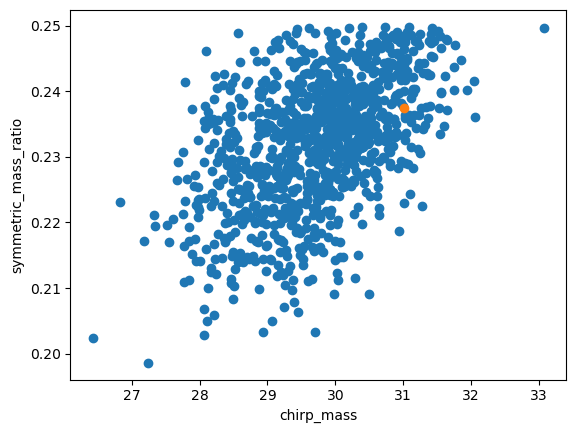

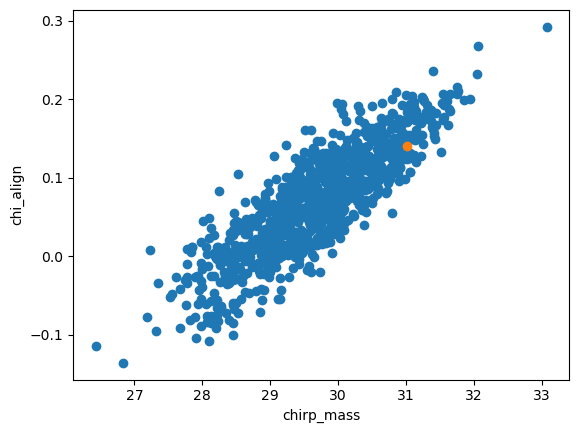

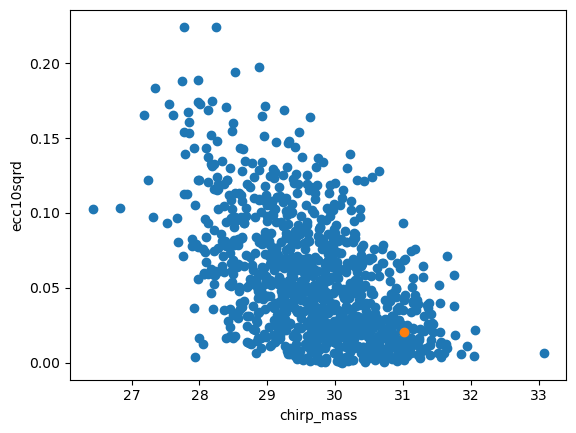

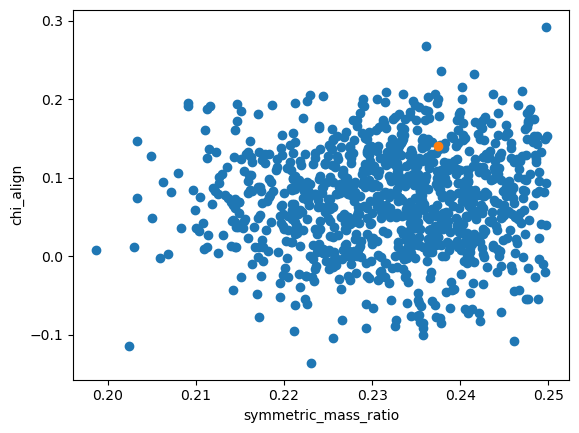

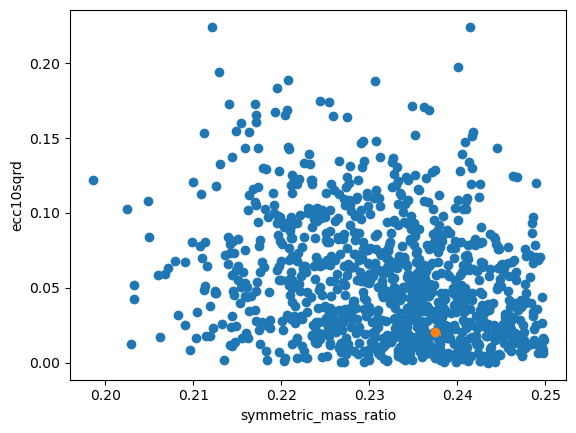

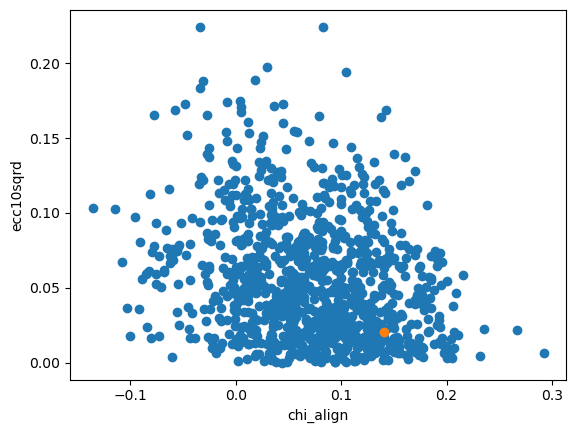

(array([0.10486496, 0.10486496, 0.12583795, 0.5033518 ,
        0.62918975, 0.88086565, 0.98573061, 1.13254155,
        1.2583795 , 1.61492036, 1.7617313 , 1.36324446,
        1.38421745, 1.59394737, 1.40519044, 1.06962258,
        1.21643352, 0.85989266, 0.65016274, 0.69210873,
        0.41945983, 0.48237881, 0.16778393, 0.18875693,
        0.16778393, 0.08389197, 0.06291898, 0.02097299,
        0.02097299, 0.02097299]),
 array([0.06161639, 0.10929676, 0.15697713, 0.2046575 ,
        0.25233787, 0.30001824, 0.34769861, 0.39537898,
        0.44305935, 0.49073972, 0.53842009, 0.58610046,
        0.63378083, 0.6814612 , 0.72914157, 0.77682194,
        0.82450231, 0.87218268, 0.91986305, 0.96754342,
        1.01522379, 1.06290416, 1.11058453, 1.1582649 ,
        1.20594527, 1.25362564, 1.30130601, 1.34898638,
        1.39666675, 1.44434712, 1.49202749]),
 [<matplotlib.patches.Polygon at 0x7fbd8a6ad930>])

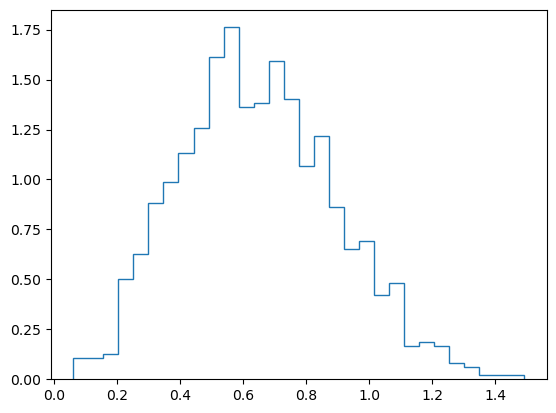

In [43]:
inj_x = [all_inj_params['posterior_samples']['chirp_mass'][0], all_inj_params['posterior_samples']['symmetric_mass_ratio'][0], all_inj_params['posterior_samples']['chi_align'][0], all_inj_params['posterior_samples']['ecc10'][0]**2]
samples = metric.generate_samples(npts=10**3)
keys = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']
for i in range(len(keys)-1):
    for j in range(i+1, len(keys)):
        plt.scatter(samples[keys[i]], samples[keys[j]])
        plt.scatter(inj_x[i], inj_x[j])
        plt.xlabel(keys[i])
        plt.ylabel(keys[j])
        plt.show()

dx_dists = []
samples_arr = np.array(samples.samples)
for i, dx in enumerate(samples.keys()):
    samples_arr[i] -= metric.x[dx][0]
x_dx_coords = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), samples_arr)
for i in range(len(samples_arr[0])):
    dx_dists.append(np.sqrt(np.sum(x_dx_coords[:,i]**2)))
plt.hist(dx_dists, bins=30, histtype='step', density=True)